# Mutation-Based Prediction of Glioma Tumor Grade

This project explores whether mutational patterns and clinical variables can predict glioma tumor grade (LGG vs GBM) using logistic regression models.

The workflow includes:
- data preprocessing,
- exploratory data analysis (EDA),
- logistic regression modelling,
- model evaluation,
- and interpretation of biologically relevant predictors.

## Importing libraries

The following libraries were used for data preprocessing, visualization, statistical analysis and logistic regression modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

import statsmodels.api as sm
import re

sns.set(style="whitegrid")

## Dataset loading and initial exploration

The original glioma mutation dataset was loaded and its structure was explored to identify the available clinical and genomic variables.

Basic information such as dataset dimensions, column names and sample observations were inspected before starting the preprocessing steps.

In [2]:
df = pd.read_csv("../data/raw/TCGA_GBM_LGG_Mutations_all.csv")

print("Dataset shape (rows, columns):", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst rows of the dataset:")
print(df.head())

Dataset shape (rows, columns): (862, 27)

Columns:
['Grade', 'Project', 'Case_ID', 'Gender', 'Age_at_diagnosis', 'Primary_Diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

First rows of the dataset:
  Grade   Project       Case_ID  Gender   Age_at_diagnosis  \
0   LGG  TCGA-LGG  TCGA-DU-8164    Male  51 years 108 days   
1   LGG  TCGA-LGG  TCGA-QH-A6CY    Male  38 years 261 days   
2   LGG  TCGA-LGG  TCGA-HW-A5KM    Male   35 years 62 days   
3   LGG  TCGA-LGG  TCGA-E1-A7YE  Female  32 years 283 days   
4   LGG  TCGA-LGG  TCGA-S9-A6WG    Male  31 years 187 days   

         Primary_Diagnosis   Race     IDH1         TP53         ATRX  ...  \
0   Oligodendroglioma, NOS  white  MUTATED  NOT_MUTATED  NOT_MUTATED  ...   
1             Mixed glioma  white  MUTATED  NOT_MUTATED  NOT_MUTATED  ...   
2         Astrocytoma, NOS  white  MUTATED      MUTAT

## Age variable preprocessing

The original age variable was stored as text values combining years and days (e.g., “51 years 108 days”).

A custom function was created to transform these values into numerical ages expressed in years, allowing their use in the logistic regression models.

In [3]:
def age_to_years(text):

    if pd.isna(text):
        return np.nan

    t = str(text)

    match_years = re.search(r'(\d+)\s*year', t)
    match_days = re.search(r'(\d+)\s*day', t)

    years = int(match_years.group(1)) if match_years else 0
    days = int(match_days.group(1)) if match_days else 0

    return years + days / 365.0


df["Age_years"] = df["Age_at_diagnosis"].apply(age_to_years)

print(df[["Age_at_diagnosis", "Age_years"]].head())

print("\nSummary statistics for Age_years:")
print(df["Age_years"].describe())

    Age_at_diagnosis  Age_years
0  51 years 108 days  51.295890
1  38 years 261 days  38.715068
2   35 years 62 days  35.169863
3  32 years 283 days  32.775342
4  31 years 187 days  31.512329

Summary statistics for Age_years:
count    862.000000
mean      50.629085
std       16.157226
min        0.000000
25%       37.440411
50%       51.390411
75%       62.634932
max       89.287671
Name: Age_years, dtype: float64


## Target variable encoding

The tumor grade variable was transformed into a binary classification problem:

- LGG = 0
- GBM = 1

This encoding allows the use of logistic regression models for tumor grade prediction.

In [4]:
print(df["Grade"].value_counts())

grade_map = {
    "LGG": 0,
    "GBM": 1
}

df["Grade_bin"] = df["Grade"].map(grade_map)

print("\nGrade_bin frequencies:")
print(df["Grade_bin"].value_counts(dropna=False))

Grade
LGG    499
GBM    363
Name: count, dtype: int64

Grade_bin frequencies:
Grade_bin
0    499
1    363
Name: count, dtype: int64


## Selection of genomic variables

A set of biologically relevant genes commonly associated with glioma progression was selected for the predictive analysis.

The availability of each genomic variable was verified before building the logistic regression models.

In [5]:
gene_cols = [
    "IDH1", "TP53", "ATRX", "PTEN", "EGFR", "CIC",
    "MUC16", "PIK3CA", "NF1", "PIK3R1", "FUBP1",
    "RB1", "NOTCH1", "BCOR", "CSMD3", "SMARCA4",
    "GRIN2A", "IDH2", "FAT4", "PDGFRA"
]

print("\nChecking genomic variables:")

for col in gene_cols:
    if col not in df.columns:
        print(f"Missing column: {col}")
    else:
        print(f"Available: {col}")


Checking genomic variables:
Available: IDH1
Available: TP53
Available: ATRX
Available: PTEN
Available: EGFR
Available: CIC
Available: MUC16
Available: PIK3CA
Available: NF1
Available: PIK3R1
Available: FUBP1
Available: RB1
Available: NOTCH1
Available: BCOR
Available: CSMD3
Available: SMARCA4
Available: GRIN2A
Available: IDH2
Available: FAT4
Available: PDGFRA


## Encoding mutational variables

The mutational status of each selected gene was transformed into binary numerical variables:

- MUTATED = 1
- NOT_MUTATED = 0

This preprocessing step allows the genomic variables to be incorporated into the logistic regression models.

In [6]:
def mut_to_bin(x):

    if x == "MUTATED":
        return 1

    elif x == "NOT_MUTATED":
        return 0

    else:
        return np.nan


for g in gene_cols:
    df[g + "_bin"] = df[g].apply(mut_to_bin)


gene_bin_cols = [g + "_bin" for g in gene_cols]

predictor_cols = gene_bin_cols + ["Age_years"]

## Final dataset preparation

Samples containing missing values in the selected predictors were removed before model training.

The final dataset was then separated into:
- predictor variables (X),
- and the target variable (y).

In [7]:
cols_model = ["Grade_bin"] + predictor_cols

df_model = df[cols_model].dropna()

print("Dataset shape after removing missing values:", df_model.shape)

X = df_model[predictor_cols]

y = df_model["Grade_bin"]

Dataset shape after removing missing values: (862, 22)


## Exploratory analysis of tumor grades and mutational frequencies

Before model training, the distribution of tumor grades and the mutational frequencies of the selected genes were explored.

This step helps identify class balance and detect genes with particularly high or low mutation prevalence.

In [8]:
print("\nTumor grade distribution:")
print(df_model["Grade_bin"].value_counts())

print("\nTumor grade percentages:")
print(df_model["Grade_bin"].value_counts(normalize=True) * 100)


print("\nGene mutation frequencies:")

mut_rates = (
    df_model[gene_bin_cols]
    .mean()
    .sort_values(ascending=False)
)

print(mut_rates)


Tumor grade distribution:
Grade_bin
0    499
1    363
Name: count, dtype: int64

Tumor grade percentages:
Grade_bin
0    57.888631
1    42.111369
Name: proportion, dtype: float64

Gene mutation frequencies:
IDH1_bin       0.480278
TP53_bin       0.410673
ATRX_bin       0.255220
PTEN_bin       0.167053
EGFR_bin       0.132251
CIC_bin        0.132251
MUC16_bin      0.116009
PIK3CA_bin     0.089327
NF1_bin        0.080046
PIK3R1_bin     0.066125
FUBP1_bin      0.054524
RB1_bin        0.047564
NOTCH1_bin     0.044084
BCOR_bin       0.033643
CSMD3_bin      0.032483
SMARCA4_bin    0.032483
GRIN2A_bin     0.031323
IDH2_bin       0.026682
FAT4_bin       0.026682
PDGFRA_bin     0.025522
dtype: float64


## Exploratory visual analysis

Several visualizations were generated to explore:
- the distribution of tumor grades,
- mutational frequencies across genes,
- mutation patterns associated with LGG and GBM,
- and correlations between genomic and clinical variables.

These analyses provide an initial overview of the biological and statistical relationships present in the dataset.

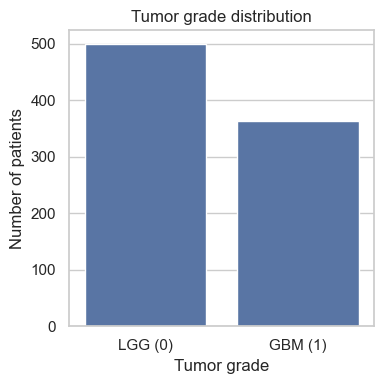

In [9]:
plt.figure(figsize=(4,4))

sns.countplot(x="Grade_bin", data=df_model)

plt.xticks([0,1], ["LGG (0)", "GBM (1)"])

plt.xlabel("Tumor grade")
plt.ylabel("Number of patients")

plt.title("Tumor grade distribution")

plt.tight_layout()
plt.show()

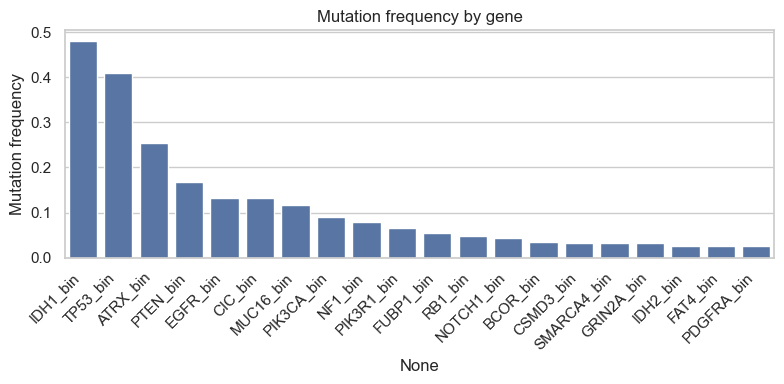

In [10]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=mut_rates.index,
    y=mut_rates.values
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Mutation frequency")

plt.title("Mutation frequency by gene")

plt.tight_layout()
plt.show()

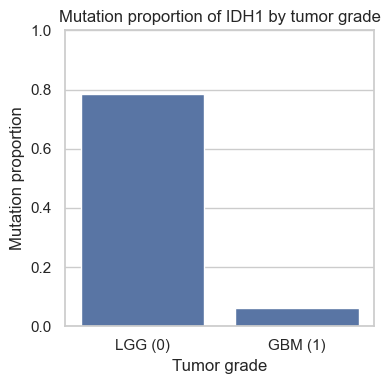

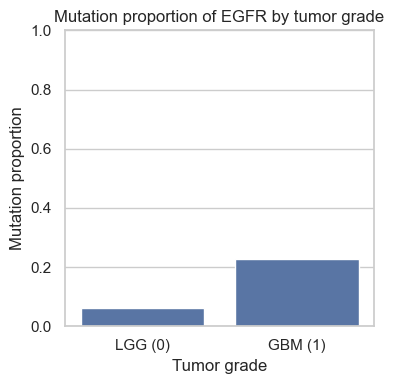

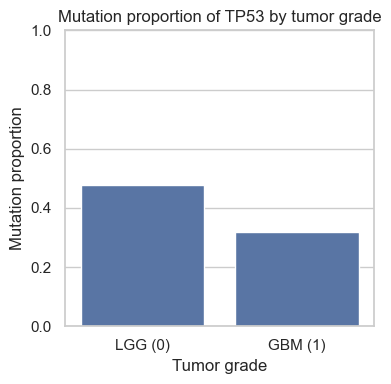

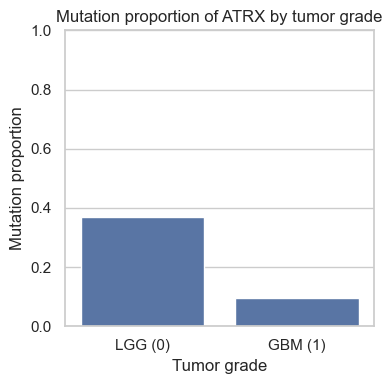

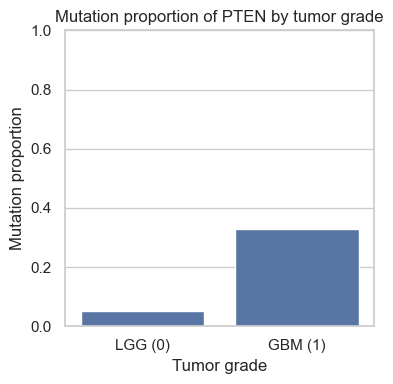

In [11]:
genes_for_plot = [
    "IDH1_bin",
    "EGFR_bin",
    "TP53_bin",
    "ATRX_bin",
    "PTEN_bin"
]

for g in genes_for_plot:

    if g not in df_model.columns:
        continue

    table = (
        df_model
        .groupby("Grade_bin")[g]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(4,4))

    sns.barplot(
        x="Grade_bin",
        y=g,
        data=table
    )

    plt.xticks([0,1], ["LGG (0)", "GBM (1)"])

    plt.ylim(0,1)

    plt.ylabel("Mutation proportion")
    plt.xlabel("Tumor grade")

    plt.title(
        f"Mutation proportion of {g.replace('_bin','')} by tumor grade"
    )

    plt.tight_layout()
    plt.show()

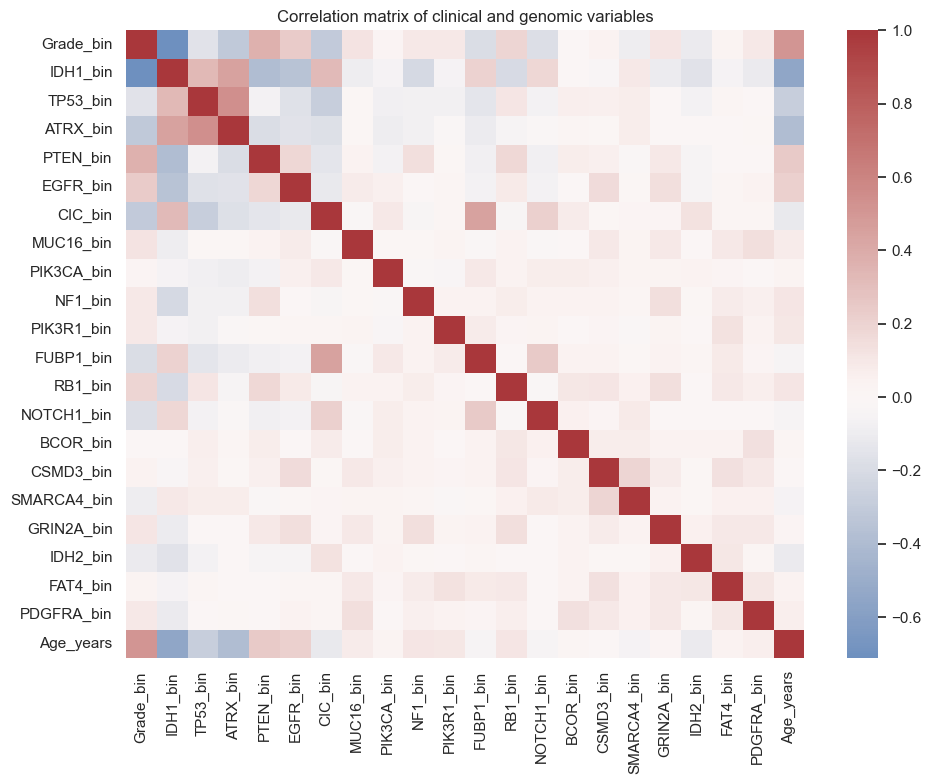

In [12]:
corr_df = df_model[
    ["Grade_bin"] + predictor_cols
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_df,
    cmap="vlag",
    center=0
)

plt.title(
    "Correlation matrix of clinical and genomic variables"
)

plt.tight_layout()
plt.show()

## Train-test split

The dataset was divided into training and testing subsets using a stratified split to preserve the proportion of LGG and GBM samples in both groups.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (603, 21)
Testing set shape: (259, 21)


## Logistic regression model

A logistic regression model was trained to predict glioma tumor grade using genomic mutational profiles and age as predictor variables.

Model performance was evaluated on both training and testing datasets to assess predictive capacity and potential overfitting.

In [14]:
logreg = LogisticRegression(max_iter=2000)

logreg.fit(X_train, y_train)


y_train_pred = logreg.predict(X_train)

y_test_pred = logreg.predict(X_test)

y_test_proba = logreg.predict_proba(X_test)[:,1]


acc_train = accuracy_score(y_train, y_train_pred)

acc_test = accuracy_score(y_test, y_test_pred)


print(f"Training accuracy: {acc_train:.3f}")

print(f"Testing accuracy: {acc_test:.3f}")


print("\nClassification report (test dataset):")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["LGG", "GBM"]
    )
)

Training accuracy: 0.872
Testing accuracy: 0.884

Classification report (test dataset):
              precision    recall  f1-score   support

         LGG       0.94      0.85      0.90       150
         GBM       0.82      0.93      0.87       109

    accuracy                           0.88       259
   macro avg       0.88      0.89      0.88       259
weighted avg       0.89      0.88      0.88       259



## Model evaluation

Several evaluation metrics were used to assess the predictive performance of the logistic regression model, including:

- confusion matrix,
- sensitivity,
- specificity,
- and ROC-AUC analysis.

These metrics help evaluate the model’s ability to discriminate between LGG and GBM tumors.


Confusion matrix:
[[128  22]
 [  8 101]]


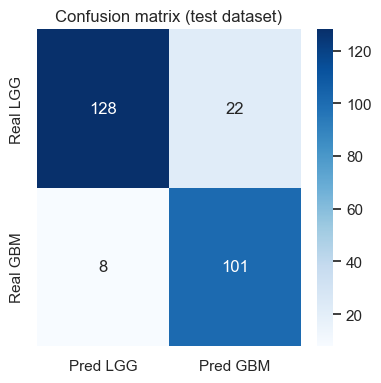

In [15]:
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion matrix:")

print(cm)


plt.figure(figsize=(4,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred LGG", "Pred GBM"],
    yticklabels=["Real LGG", "Real GBM"]
)

plt.title("Confusion matrix (test dataset)")

plt.tight_layout()

plt.show()

In [16]:
tn, fp, fn, tp = cm.ravel()

sens = tp / (tp + fn)

spec = tn / (tn + fp)


print(f"GBM sensitivity: {sens:.3f}")

print(f"LGG specificity: {spec:.3f}")

GBM sensitivity: 0.927
LGG specificity: 0.853


## ROC curve analysis

Receiver Operating Characteristic (ROC) analysis was performed to evaluate the discriminative capacity of the logistic regression model across different classification thresholds.

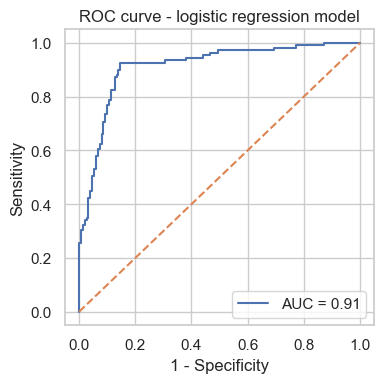

In [17]:
fpr, tpr, thr = roc_curve(
    y_test,
    y_test_proba
)

auc = roc_auc_score(
    y_test,
    y_test_proba
)


plt.figure(figsize=(4,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("1 - Specificity")

plt.ylabel("Sensitivity")

plt.title("ROC curve - logistic regression model")

plt.legend()

plt.tight_layout()

plt.show()

## Statistical interpretation of predictor variables

A logistic regression model using `statsmodels` was fitted to estimate Odds Ratios (OR) and confidence intervals for the selected predictor variables.

This analysis helps identify which genomic and clinical variables are most strongly associated with glioma tumor grade.

In [18]:
X_train_sm = sm.add_constant(X_train)


logit_model = sm.Logit(
    y_train,
    X_train_sm
)

result = logit_model.fit()


print(result.summary())


params = result.params

conf = result.conf_int()

conf.columns = ["2.5%", "97.5%"]


or_vals = np.exp(params)

or_ci_low = np.exp(conf["2.5%"])

or_ci_high = np.exp(conf["97.5%"])


or_table = pd.DataFrame({
    "OR": or_vals,
    "CI_2.5%": or_ci_low,
    "CI_97.5%": or_ci_high
})


or_table_no_const = or_table.drop(index="const")


print("\nOdds Ratio table:")

print(
    or_table_no_const
    .sort_values("OR", ascending=False)
)

         Current function value: 0.303286
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:              Grade_bin   No. Observations:                  603
Model:                          Logit   Df Residuals:                      581
Method:                           MLE   Df Model:                           21
Date:                Fri, 08 May 2026   Pseudo R-squ.:                  0.5544
Time:                        13:20:20   Log-Likelihood:                -182.88
converged:                      False   LL-Null:                       -410.45
Covariance Type:            nonrobust   LLR p-value:                 3.339e-83
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6273      0.620     -1.011      0.312      -1.843       0.589
IDH1_bin       -4.4335      0.527     -8.412      0.000      -

C:\Users\juanc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\juanc\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Biological interpretation of Odds Ratios

Odds Ratios and confidence intervals were used to interpret the association between specific genomic variables and glioma tumor grade.

Variables with OR > 1 were associated with a higher probability of GBM, while variables with OR < 1 were more frequently associated with LGG tumors.

In [19]:
interpretation = []

for var, row in or_table_no_const.iterrows():

    or_val = row["OR"]

    low = row["CI_2.5%"]

    high = row["CI_97.5%"]


    if low > 1:

        interpretation.append(
            f"{var}: OR={or_val:.2f} "
            f"(95% CI {low:.2f}-{high:.2f}) "
            f"-> associated with higher probability of GBM."
        )

    elif high < 1:

        interpretation.append(
            f"{var}: OR={or_val:.2f} "
            f"(95% CI {low:.2f}-{high:.2f}) "
            f"-> associated with lower probability of GBM."
        )

    else:

        interpretation.append(
            f"{var}: OR={or_val:.2f} "
            f"(95% CI {low:.2f}-{high:.2f}) "
            f"-> inconclusive association."
        )


print("\nInterpretation of Odds Ratios:\n")

for line in interpretation:

    print("-", line)


Interpretation of Odds Ratios:

- IDH1_bin: OR=0.01 (95% CI 0.00-0.03) -> associated with lower probability of GBM.
- TP53_bin: OR=3.00 (95% CI 1.34-6.72) -> associated with higher probability of GBM.
- ATRX_bin: OR=1.05 (95% CI 0.40-2.73) -> inconclusive association.
- PTEN_bin: OR=1.76 (95% CI 0.84-3.65) -> inconclusive association.
- EGFR_bin: OR=0.61 (95% CI 0.31-1.20) -> inconclusive association.
- CIC_bin: OR=0.22 (95% CI 0.02-2.13) -> inconclusive association.
- MUC16_bin: OR=2.51 (95% CI 1.06-5.96) -> associated with higher probability of GBM.
- PIK3CA_bin: OR=0.81 (95% CI 0.31-2.14) -> inconclusive association.
- NF1_bin: OR=0.34 (95% CI 0.15-0.77) -> associated with lower probability of GBM.
- PIK3R1_bin: OR=4.15 (95% CI 1.30-13.21) -> associated with higher probability of GBM.
- FUBP1_bin: OR=2.04 (95% CI 0.09-47.51) -> inconclusive association.
- RB1_bin: OR=2.26 (95% CI 0.45-11.35) -> inconclusive association.
- NOTCH1_bin: OR=0.00 (95% CI 0.00-inf) -> inconclusive associ

## Reduced logistic regression model

A reduced model including the most biologically relevant predictor variables was generated to evaluate whether similar predictive performance could be achieved with fewer genomic features.

This approach improves model interpretability while reducing complexity.

In [20]:
pred_reduced = [
    "IDH1_bin",
    "IDH2_bin",
    "TP53_bin",
    "MUC16_bin",
    "NF1_bin",
    "Age_years"
]


X_red = df_model[pred_reduced]


X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_red,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


logreg_r = LogisticRegression(max_iter=2000)

logreg_r.fit(X_train_r, y_train_r)


y_test_pred_r = logreg_r.predict(X_test_r)

acc_test_r = accuracy_score(
    y_test_r,
    y_test_pred_r
)


print(f"Reduced model accuracy: {acc_test_r:.3f}")

Reduced model accuracy: 0.876


## Statistical analysis of the reduced model

The reduced logistic regression model was additionally evaluated using `statsmodels` to obtain statistical summaries and assess the contribution of the selected predictor variables.

In [21]:
X_train_r_sm = sm.add_constant(X_train_r)

logit_red = sm.Logit(
    y_train_r,
    X_train_r_sm
)

result_red = logit_red.fit()


print(result_red.summary())

Optimization terminated successfully.
         Current function value: 0.329480
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Grade_bin   No. Observations:                  603
Model:                          Logit   Df Residuals:                      596
Method:                           MLE   Df Model:                            6
Date:                Fri, 08 May 2026   Pseudo R-squ.:                  0.5160
Time:                        13:20:21   Log-Likelihood:                -198.68
converged:                       True   LL-Null:                       -410.45
Covariance Type:            nonrobust   LLR p-value:                 2.407e-88
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6121      0.575     -1.065      0.287      -1.739       0.515
IDH1_bin      -4.5281      0.

## Exporting the processed dataset

The final cleaned dataset used for modelling was exported for reproducibility and downstream analyses.

In [22]:
df_model.to_csv(
    "../data/processed/df_model_clean.csv",
    index=False
)

## Predictions using the reduced logistic regression model

Predicted probabilities and final classifications were generated for the testing dataset using the reduced logistic regression model.

In [23]:
X_test_r_sm = sm.add_constant(
    X_test_r,
    has_constant="add"
)

test_data = X_test_r.copy()

test_data["Grade_bin"] = y_test_r.values

test_data["prob_red"] = result_red.predict(
    X_test_r_sm
)

test_data["pred_red"] = (
    test_data["prob_red"] >= 0.5
).astype(int)

## Exporting model predictions

Predicted probabilities and classifications from the reduced model were exported for downstream analysis and result interpretation.

In [24]:
test_output = test_data[
    ["Grade_bin", "prob_red", "pred_red"]
]

test_output.to_csv(
    "../data/processed/model_predictions.csv",
    index=False
)

## Exporting Odds Ratios from the reduced model

Odds Ratios and confidence intervals obtained from the reduced logistic regression model were exported for downstream analysis and figure generation.

In [25]:
params_red = result_red.params

conf_red = result_red.conf_int()

conf_red.columns = ["CI_2.5%", "CI_97.5%"]


or_vals_red = np.exp(params_red)

or_ci_low_red = np.exp(
    conf_red["CI_2.5%"]
)

or_ci_high_red = np.exp(
    conf_red["CI_97.5%"]
)


or_table_red = pd.DataFrame({
    "term": or_vals_red.index,
    "OR": or_vals_red.values,
    "CI_low": or_ci_low_red.values,
    "CI_high": or_ci_high_red.values
})


or_table_red = or_table_red[
    or_table_red["term"] != "const"
]


or_table_red.to_csv(
    "../data/processed/or_reduced.csv",
    index=False
)

# Conclusions
This project explored the use of genomic mutational profiles and clinical variables to predict glioma tumor grade using logistic regression models.

The results showed that several variables, including IDH1, IDH2, TP53, NF1, MUC16 and age, were associated with tumor classification. The reduced model maintained good predictive performance while improving interpretability.

Overall, this analysis demonstrates how statistical modelling and genomic data can be integrated to study clinically relevant patterns in gliomas.